# CoG vs Fundamentalness Correlation Analysis (ALL MEASURES)

This notebook correlates LLM polarization **depth** (Center of Gravity) with **ALL fundamentalness measures** (~85 measures) computed from GSS survey data.

**Fundamentalness measures** include:

**Network Variants:**
- Complete graph (no threshold)
- Thresholded graphs (|corr| > 0.05, 0.1, 0.15, 0.2)
- Log-transformed distance
- Squared correlation

**Centrality Types (for each network variant):**
- betweenness, betweenness_unw, closeness, harmonic, eigenvector, pagerank, degree, strength, katz

**Tree Measures (Chow-Liu MST):**
- tree_betweenness
- For each root selection (max_neighbor_mi, max_degree, center):
  - depth, depth_inv, depth_norm, subtree, hierarchy

**MI/Correlation Based:**
- mi_sum, mi_mean, mi_max
- corr_abs_sum, corr_abs_mean

**Models used (4 models):**
- Llama-3.1-8B, Gemma-2-9b, Mistral-7B-v0.2, Qwen3-8B

**CoG normalization:** Z-score within each model before averaging

In [24]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mutual_info_score
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration
LLM_RESULTS_DIR = Path('/project/jevans/maxzhuyt/gss_polarization/llm_polarization/results')
GSS_DEPTH_DIR = Path('/project/jevans/maxzhuyt/gss_polarization/question_fundamentalness')
RESULTS_DIR = GSS_DEPTH_DIR / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

# LLM combined results with CoG
LLM_COMBINED_FILE = LLM_RESULTS_DIR / 'df_gss_2cat_combined_20260128_230153.pkl'

# Models to use (4 models only)
MODELS_TO_USE = ['Llama-3.1-8B', 'Gemma-2-9b', 'Mistral-7B-v0.2', 'Qwen3-8B']

print("Configuration:")
print(f"  LLM results: {LLM_COMBINED_FILE}")
print(f"  GSS data dir: {GSS_DEPTH_DIR}")
print(f"  Results dir: {RESULTS_DIR}")
print(f"  Models: {MODELS_TO_USE}")

Configuration:
  LLM results: /project/jevans/maxzhuyt/gss_polarization/llm_polarization/results/df_gss_2cat_combined_20260128_230153.pkl
  GSS data dir: /project/jevans/maxzhuyt/gss_polarization/question_fundamentalness
  Results dir: /project/jevans/maxzhuyt/gss_polarization/question_fundamentalness/results
  Models: ['Llama-3.1-8B', 'Gemma-2-9b', 'Mistral-7B-v0.2', 'Qwen3-8B']


## 1. Load Data

In [25]:
# Load LLM results with CoG
df_llm = pd.read_pickle(LLM_COMBINED_FILE)
print(f"LLM data: {len(df_llm)} rows")
print(f"All models: {df_llm['model'].unique().tolist()}")
print(f"Categories: {df_llm['category'].unique().tolist()}")

# Filter to 4 models only
df_llm = df_llm[df_llm['model'].isin(MODELS_TO_USE)]
print(f"\nFiltered to {len(MODELS_TO_USE)} models: {len(df_llm)} rows")

# Normalize CoG within each model (z-score) before averaging
def normalize_cog(group):
    """Z-score normalize CoG within each model."""
    group = group.copy()
    mean_cog = group['Polarization_CoG'].mean()
    std_cog = group['Polarization_CoG'].std()
    if std_cog > 0:
        group['CoG_normalized'] = (group['Polarization_CoG'] - mean_cog) / std_cog
    else:
        group['CoG_normalized'] = 0
    return group

df_llm = df_llm.groupby('model', group_keys=False).apply(normalize_cog)

# Show normalization effect
print("\nCoG statistics per model (before and after normalization):")
for model in MODELS_TO_USE:
    model_data = df_llm[df_llm['model'] == model]
    raw_mean = model_data['Polarization_CoG'].mean()
    raw_std = model_data['Polarization_CoG'].std()
    norm_mean = model_data['CoG_normalized'].mean()
    norm_std = model_data['CoG_normalized'].std()
    print(f"  {model}: raw={raw_mean:.2f}±{raw_std:.2f}, normalized={norm_mean:.3f}±{norm_std:.3f}")

# Average normalized CoG across models per topic
df_cog = df_llm.groupby(['Topic', 'category']).agg({
    'Polarization_CoG': 'mean',
    'CoG_normalized': 'mean',
    'Avg_Mahalanobis': 'mean'
}).reset_index()
df_cog = df_cog.rename(columns={'Topic': 'variable'})
print(f"\nUnique topics with CoG: {len(df_cog)}")

LLM data: 1194 rows
All models: ['Llama-3.1-8B', 'DeepSeek-R1-Qwen-14B', 'Mistral-7B-v0.2', 'Gemma-2-9b', 'Qwen3-8B', 'Phi-4-reasoing-plus-7B']
Categories: ['public_issues', 'private_life']

Filtered to 4 models: 796 rows

CoG statistics per model (before and after normalization):
  Llama-3.1-8B: raw=16.85±0.81, normalized=-0.000±1.000
  Gemma-2-9b: raw=23.56±0.56, normalized=-0.000±1.000
  Mistral-7B-v0.2: raw=16.64±0.44, normalized=-0.000±1.000
  Qwen3-8B: raw=19.94±0.49, normalized=0.000±1.000

Unique topics with CoG: 199


In [26]:
# Load GSS survey data
df_gss = pd.read_csv(GSS_DEPTH_DIR / 'gss_2021_2024.csv')
print(f"GSS survey data: {len(df_gss)} respondents")

# Get variable lists from LLM combined file (only analyze variables with CoG data)
llm_public_vars = df_cog[df_cog['category'] == 'public_issues']['variable'].tolist()
llm_private_vars = df_cog[df_cog['category'] == 'private_life']['variable'].tolist()

print(f"\nVariables in LLM data:")
print(f"  Public issues: {len(llm_public_vars)}")
print(f"  Private life: {len(llm_private_vars)}")

# Filter to variables that exist in GSS survey data
public_vars = [v for v in llm_public_vars if v in df_gss.columns]
private_vars = [v for v in llm_private_vars if v in df_gss.columns]

print(f"\nVariables in both LLM and GSS data:")
print(f"  Public issues: {len(public_vars)}")
print(f"  Private life: {len(private_vars)}")

# Report variables missing from GSS
missing_public = set(llm_public_vars) - set(public_vars)
missing_private = set(llm_private_vars) - set(private_vars)
if missing_public:
    print(f"\n  Missing from GSS (public): {sorted(missing_public)[:10]}{'...' if len(missing_public) > 10 else ''}")
if missing_private:
    print(f"  Missing from GSS (private): {sorted(missing_private)[:10]}{'...' if len(missing_private) > 10 else ''}")

GSS survey data: 11066 respondents

Variables in LLM data:
  Public issues: 126
  Private life: 73

Variables in both LLM and GSS data:
  Public issues: 126
  Private life: 73


## 2. Compute Fundamentalness Measures

In [27]:
def preprocess_gss_data(df, variables, min_valid=100):
    """Preprocess GSS data for analysis."""
    # Filter to variables that exist in the data
    valid_vars = [v for v in variables if v in df.columns]
    
    # Convert invalid responses to NaN (GSS: 0, 8, 9, negative = invalid)
    df_subset = df[valid_vars].copy()
    for col in valid_vars:
        if pd.api.types.is_numeric_dtype(df_subset[col]):
            df_subset.loc[df_subset[col] <= 0, col] = np.nan
            df_subset.loc[df_subset[col] >= 8, col] = np.nan
    
    # Filter variables with enough valid responses
    valid_counts = df_subset.notna().sum()
    final_vars = valid_counts[valid_counts >= min_valid].index.tolist()
    
    return df_subset, final_vars


def compute_correlation_matrix(df, variables, min_samples=30):
    """Compute pairwise Spearman correlations."""
    n = len(variables)
    corr_matrix = pd.DataFrame(np.nan, index=variables, columns=variables)
    
    for i, q1 in enumerate(variables):
        corr_matrix.loc[q1, q1] = 1.0
        for j, q2 in enumerate(variables):
            if j <= i:
                continue
            x = df[q1].values
            y = df[q2].values
            mask = ~(np.isnan(x) | np.isnan(y))
            if mask.sum() >= min_samples:
                corr, _ = stats.spearmanr(x[mask], y[mask])
                corr_matrix.loc[q1, q2] = corr
                corr_matrix.loc[q2, q1] = corr
    
    return corr_matrix


def compute_mi_matrix(df, variables, min_samples=30):
    """Compute pairwise mutual information."""
    n = len(variables)
    mi_matrix = pd.DataFrame(0.0, index=variables, columns=variables)
    
    for i, q1 in enumerate(variables):
        for j, q2 in enumerate(variables):
            if j <= i:
                continue
            x = df[q1].values
            y = df[q2].values
            mask = ~(np.isnan(x) | np.isnan(y))
            if mask.sum() >= min_samples:
                try:
                    mi = mutual_info_score(x[mask].astype(int), y[mask].astype(int))
                    mi_matrix.loc[q1, q2] = mi
                    mi_matrix.loc[q2, q1] = mi
                except:
                    pass
    
    return mi_matrix

In [28]:
def build_network_variants(corr_matrix, variables):
    """Build multiple network variants with different thresholds and transforms."""
    variants = {}
    
    # Variant 1: Complete graph, distance = 1 - |corr|
    G_complete = nx.Graph()
    G_complete.add_nodes_from(variables)
    for i, q1 in enumerate(variables):
        for j, q2 in enumerate(variables):
            if j <= i:
                continue
            corr = corr_matrix.loc[q1, q2]
            if np.isnan(corr):
                abs_corr = 0.01
            else:
                abs_corr = max(abs(corr), 0.01)
            G_complete.add_edge(q1, q2, weight=abs_corr, distance=1-abs_corr)
    variants['complete'] = G_complete
    
    # Variant 2: Thresholded graphs
    for threshold in [0.05, 0.1, 0.15, 0.2]:
        G_thresh = nx.Graph()
        G_thresh.add_nodes_from(variables)
        for i, q1 in enumerate(variables):
            for j, q2 in enumerate(variables):
                if j <= i:
                    continue
                corr = corr_matrix.loc[q1, q2]
                if not np.isnan(corr) and abs(corr) > threshold:
                    abs_corr = abs(corr)
                    G_thresh.add_edge(q1, q2, weight=abs_corr, distance=1-abs_corr)
        variants[f'thresh_{threshold}'] = G_thresh
    
    # Variant 3: Log-transformed distance
    G_log = nx.Graph()
    G_log.add_nodes_from(variables)
    for i, q1 in enumerate(variables):
        for j, q2 in enumerate(variables):
            if j <= i:
                continue
            corr = corr_matrix.loc[q1, q2]
            if np.isnan(corr):
                abs_corr = 0.01
            else:
                abs_corr = max(abs(corr), 0.01)
            G_log.add_edge(q1, q2, weight=abs_corr, distance=-np.log(abs_corr))
    variants['complete_log'] = G_log
    
    # Variant 4: Squared correlation
    G_sq = nx.Graph()
    G_sq.add_nodes_from(variables)
    for i, q1 in enumerate(variables):
        for j, q2 in enumerate(variables):
            if j <= i:
                continue
            corr = corr_matrix.loc[q1, q2]
            if np.isnan(corr):
                corr_sq = 0.0001
            else:
                corr_sq = corr ** 2
            G_sq.add_edge(q1, q2, weight=corr_sq, distance=1-corr_sq)
    variants['complete_squared'] = G_sq
    
    return variants


def compute_network_centralities(G, name):
    """Compute various centrality measures for a network."""
    results = {}
    n_nodes = G.number_of_nodes()
    n_edges = G.number_of_edges()
    
    # Only compute if graph has edges
    if n_edges == 0:
        return {f'{name}_{m}': pd.Series(0, index=G.nodes())
                for m in ['betweenness', 'betweenness_unw', 'closeness', 'harmonic', 
                          'eigenvector', 'pagerank', 'degree', 'strength', 'katz']}
    
    # Betweenness (weighted by distance)
    try:
        results[f'{name}_betweenness'] = pd.Series(nx.betweenness_centrality(G, weight='distance'))
    except:
        results[f'{name}_betweenness'] = pd.Series(0, index=G.nodes())
    
    # Betweenness (unweighted)
    try:
        results[f'{name}_betweenness_unw'] = pd.Series(nx.betweenness_centrality(G))
    except:
        results[f'{name}_betweenness_unw'] = pd.Series(0, index=G.nodes())
    
    # Closeness (weighted)
    try:
        results[f'{name}_closeness'] = pd.Series(nx.closeness_centrality(G, distance='distance'))
    except:
        results[f'{name}_closeness'] = pd.Series(0, index=G.nodes())
    
    # Harmonic centrality
    try:
        results[f'{name}_harmonic'] = pd.Series(nx.harmonic_centrality(G, distance='distance'))
    except:
        results[f'{name}_harmonic'] = pd.Series(0, index=G.nodes())
    
    # Eigenvector (weighted)
    try:
        results[f'{name}_eigenvector'] = pd.Series(nx.eigenvector_centrality(G, weight='weight', max_iter=1000))
    except:
        results[f'{name}_eigenvector'] = pd.Series(0, index=G.nodes())
    
    # PageRank
    try:
        results[f'{name}_pagerank'] = pd.Series(nx.pagerank(G, weight='weight'))
    except:
        results[f'{name}_pagerank'] = pd.Series(0, index=G.nodes())
    
    # Degree centrality
    results[f'{name}_degree'] = pd.Series(nx.degree_centrality(G))
    
    # Weighted degree (strength)
    strength = {n: sum(d['weight'] for _, _, d in G.edges(n, data=True)) for n in G.nodes()}
    results[f'{name}_strength'] = pd.Series(strength)
    
    # Katz centrality
    try:
        results[f'{name}_katz'] = pd.Series(nx.katz_centrality(G, weight='weight'))
    except:
        results[f'{name}_katz'] = pd.Series(0, index=G.nodes())
    
    return results

In [29]:
def build_tree_variants(mi_matrix, variables):
    """Build Chow-Liu tree with different root selection methods."""
    # Build graph from MI
    G = nx.Graph()
    for i, q1 in enumerate(variables):
        for j, q2 in enumerate(variables):
            if j <= i:
                continue
            mi = mi_matrix.loc[q1, q2]
            if mi > 0:
                G.add_edge(q1, q2, weight=mi)
    
    if G.number_of_edges() == 0:
        return None, None
    
    # Maximum spanning tree
    mst = nx.maximum_spanning_tree(G, weight='weight')
    
    # Different root selection methods
    roots = {}
    
    # Method 1: Max neighbor MI sum
    neighbor_mi = {n: sum(mst[n][nb]['weight'] for nb in mst.neighbors(n)) for n in mst.nodes()}
    roots['max_neighbor_mi'] = max(neighbor_mi, key=neighbor_mi.get)
    
    # Method 2: Max degree
    degrees = dict(mst.degree())
    roots['max_degree'] = max(degrees, key=degrees.get)
    
    # Method 3: Center of tree
    try:
        center = nx.center(mst)[0]
        roots['center'] = center
    except:
        roots['center'] = roots['max_neighbor_mi']
    
    return mst, roots


def compute_tree_metrics_for_root(tree, root, variables, prefix):
    """Compute tree metrics with a specific root."""
    results = {}
    
    # Depth from root
    depths = nx.single_source_shortest_path_length(tree, root)
    results[f'{prefix}_depth'] = pd.Series(depths)
    
    # Inverse depth (shallower = higher score)
    max_depth = max(depths.values())
    if max_depth > 0:
        results[f'{prefix}_depth_inv'] = pd.Series({n: max_depth - d for n, d in depths.items()})
        results[f'{prefix}_depth_norm'] = pd.Series({n: 1 - d/max_depth for n, d in depths.items()})
    else:
        results[f'{prefix}_depth_inv'] = pd.Series(0, index=variables)
        results[f'{prefix}_depth_norm'] = pd.Series(1, index=variables)
    
    # Subtree size
    directed = nx.bfs_tree(tree, root)
    subtree_sizes = {}
    for node in tree.nodes():
        if node in directed:
            subtree_sizes[node] = len(nx.descendants(directed, node))
        else:
            subtree_sizes[node] = 0
    results[f'{prefix}_subtree'] = pd.Series(subtree_sizes)
    
    # Hierarchy centrality (same as depth_norm)
    results[f'{prefix}_hierarchy'] = results[f'{prefix}_depth_norm'].copy()
    
    return results

In [30]:
def compute_all_fundamentalness_measures(df, variables):
    """Compute ALL fundamentalness measures (~85) for a set of variables."""
    print(f"  Computing matrices for {len(variables)} variables...")
    
    # Compute base matrices
    corr_matrix = compute_correlation_matrix(df, variables)
    mi_matrix = compute_mi_matrix(df, variables)
    
    # Initialize results
    all_results = pd.DataFrame(index=variables)
    
    # ========== NETWORK MEASURES ==========
    print("  Building network variants...")
    network_variants = build_network_variants(corr_matrix, variables)
    
    for name, G in network_variants.items():
        print(f"    {name}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
        centralities = compute_network_centralities(G, name)
        for col, values in centralities.items():
            if isinstance(values, pd.Series):
                all_results[col] = values
    
    # ========== TREE MEASURES ==========
    print("  Building tree variants...")
    mst, roots = build_tree_variants(mi_matrix, variables)
    
    if mst is not None:
        print(f"    MST: {mst.number_of_nodes()} nodes, {mst.number_of_edges()} edges")
        
        # Tree betweenness (same for all roots)
        tree_betweenness = nx.betweenness_centrality(mst)
        all_results['tree_betweenness'] = pd.Series(tree_betweenness)
        
        # Compute metrics for each root selection method
        for root_method, root in roots.items():
            print(f"    Root ({root_method}): {root}")
            tree_metrics = compute_tree_metrics_for_root(mst, root, variables, f'tree_{root_method}')
            for col, values in tree_metrics.items():
                all_results[col] = values
    
    # ========== MI-BASED MEASURES ==========
    all_results['mi_sum'] = mi_matrix.sum(axis=1)
    all_results['mi_mean'] = mi_matrix.mean(axis=1)
    all_results['mi_max'] = mi_matrix.max(axis=1)
    
    # ========== CORRELATION-BASED MEASURES ==========
    all_results['corr_abs_sum'] = corr_matrix.abs().sum(axis=1) - 1  # subtract self
    all_results['corr_abs_mean'] = (corr_matrix.abs().sum(axis=1) - 1) / (len(variables) - 1)
    
    all_results = all_results.reset_index().rename(columns={'index': 'variable'})
    
    print(f"  Computed {len(all_results.columns) - 1} measures for {len(all_results)} variables")
    
    return all_results

In [31]:
# Compute fundamentalness for PUBLIC ISSUES
print("="*60)
print("COMPUTING FUNDAMENTALNESS: PUBLIC ISSUES")
print("="*60)

df_public, valid_public_vars = preprocess_gss_data(df_gss, public_vars)
print(f"Valid public variables: {len(valid_public_vars)}")

fund_public = compute_all_fundamentalness_measures(df_public, valid_public_vars)
fund_public['category'] = 'public_issues'
print(f"Computed {len(fund_public.columns)-2} measures for {len(fund_public)} variables")

COMPUTING FUNDAMENTALNESS: PUBLIC ISSUES
Valid public variables: 126
  Computing matrices for 126 variables...


  Building network variants...
    complete: 126 nodes, 7875 edges
    thresh_0.05: 126 nodes, 5130 edges
    thresh_0.1: 126 nodes, 3582 edges
    thresh_0.15: 126 nodes, 2460 edges
    thresh_0.2: 126 nodes, 1647 edges
    complete_log: 126 nodes, 7875 edges
    complete_squared: 126 nodes, 7875 edges
  Building tree variants...
    MST: 126 nodes, 125 edges
    Root (max_neighbor_mi): grnexagg
    Root (max_degree): grnexagg
    Root (center): helppoor
  Computed 84 measures for 126 variables
Computed 84 measures for 126 variables


In [32]:
fund_public

,variable,complete_betweenness,complete_betweenness_unw,complete_closeness,complete_harmonic,complete_eigenvector,complete_pagerank,complete_degree,complete_strength,complete_katz,...,tree_center_depth_inv,tree_center_depth_norm,tree_center_subtree,tree_center_hierarchy,mi_sum,mi_mean,mi_max,corr_abs_sum,corr_abs_mean,category
0,abdefect,0.0,0.0,1.184207,152.916942,0.102740,0.009684,1.0,19.444164,0,...,3,0.272727,2,0.272727,2.728745,0.021657,0.161050,19.424458,0.155396,public_issues
1,abhelp1,0.0,0.0,1.146853,149.435701,0.082867,0.008195,1.0,15.993452,0,...,5,0.454545,9,0.454545,2.447192,0.019422,0.193486,15.517435,0.124139,public_issues
2,abhelp2,0.0,0.0,1.175213,152.430926,0.096161,0.009258,1.0,18.445392,0,...,7,0.636364,14,0.636364,3.112677,0.024704,0.251082,17.985392,0.143883,public_issues
3,abhelp3,0.0,0.0,1.169028,152.300277,0.094095,0.009066,1.0,18.018874,0,...,6,0.545455,12,0.545455,2.945442,0.023377,0.251082,17.552060,0.140416,public_issues
4,abhelp4,0.0,0.0,1.096202,138.934354,0.055644,0.006011,1.0,10.969930,0,...,4,0.363636,0,0.363636,1.063091,0.008437,0.091288,10.505573,0.084045,public_issues
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,tax,0.0,0.0,1.109524,139.547628,0.064282,0.006613,1.0,12.339076,0,...,6,0.545455,0,0.545455,1.299077,0.010310,0.076606,12.305894,0.098447,public_issues
122,tempgen1,0.0,0.0,1.278315,170.365381,0.155484,0.012735,1.0,26.883590,0,...,8,0.727273,14,0.727273,6.710843,0.053261,0.322694,26.620553,0.212964,public_issues
123,toodifme,0.0,0.0,1.109957,140.417437,0.066945,0.006583,1.0,12.383056,0,...,7,0.636364,2,0.636364,2.678151,0.021255,0.164272,12.121534,0.096972,public_issues
124,viggrp,0.0,0.0,1.050601,131.801052,0.031352,0.003852,1.0,6.020505,0,...,9,0.818182,0,0.818182,0.727035,0.005770,0.048225,5.431416,0.043451,public_issues


In [33]:
# Compute fundamentalness for PRIVATE LIFE
print("="*60)
print("COMPUTING FUNDAMENTALNESS: PRIVATE LIFE")
print("="*60)

df_private, valid_private_vars = preprocess_gss_data(df_gss, private_vars)
print(f"Valid private variables: {len(valid_private_vars)}")

fund_private = compute_all_fundamentalness_measures(df_private, valid_private_vars)
fund_private['category'] = 'private_life'
print(f"Computed {len(fund_private.columns)-2} measures for {len(fund_private)} variables")

COMPUTING FUNDAMENTALNESS: PRIVATE LIFE
Valid private variables: 72
  Computing matrices for 72 variables...
  Building network variants...
    complete: 72 nodes, 2556 edges
    thresh_0.05: 72 nodes, 1163 edges
    thresh_0.1: 72 nodes, 584 edges
    thresh_0.15: 72 nodes, 351 edges
    thresh_0.2: 72 nodes, 224 edges
    complete_log: 72 nodes, 2556 edges
    complete_squared: 72 nodes, 2556 edges
  Building tree variants...
    MST: 72 nodes, 71 edges
    Root (max_neighbor_mi): emailmin
    Root (max_degree): emailmin
    Root (center): wwwhr
  Computed 84 measures for 72 variables
Computed 84 measures for 72 variables


## 3. Merge with CoG Data

In [34]:
# Merge fundamentalness with CoG (using normalized CoG)
df_cog_public = df_cog[df_cog['category'] == 'public_issues'].copy()
df_cog_private = df_cog[df_cog['category'] == 'private_life'].copy()

merged_public = fund_public.merge(
    df_cog_public[['variable', 'Polarization_CoG', 'CoG_normalized']], 
    on='variable', how='inner'
)
merged_private = fund_private.merge(
    df_cog_private[['variable', 'Polarization_CoG', 'CoG_normalized']], 
    on='variable', how='inner'
)

print(f"Public issues: {len(merged_public)} variables with both fundamentalness and CoG")
print(f"Private life: {len(merged_private)} variables with both fundamentalness and CoG")

Public issues: 126 variables with both fundamentalness and CoG
Private life: 72 variables with both fundamentalness and CoG


## 4. Correlation Analysis

In [35]:
def compute_correlations_with_cog(df_merged, cog_col='CoG_normalized'):
    """Compute correlations between all fundamentalness measures and normalized CoG."""
    results = []
    
    # Get measure columns (exclude metadata)
    exclude_cols = ['variable', 'category', 'Polarization_CoG', 'CoG_normalized', 'Avg_Mahalanobis']
    measure_cols = [c for c in df_merged.columns if c not in exclude_cols]
    
    for col in measure_cols:
        valid = df_merged[[cog_col, col]].dropna()
        if len(valid) >= 10:
            # Check for constant values
            if valid[col].std() == 0:
                continue
            pearson_r, pearson_p = stats.pearsonr(valid[cog_col], valid[col])
            spearman_r, spearman_p = stats.spearmanr(valid[cog_col], valid[col])
            results.append({
                'measure': col,
                'n': len(valid),
                'pearson_r': pearson_r,
                'pearson_p': pearson_p,
                'spearman_r': spearman_r,
                'spearman_p': spearman_p
            })
    
    return pd.DataFrame(results).sort_values('spearman_r', ascending=False)

def stars(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    return ''

In [36]:
# PUBLIC ISSUES correlations
print("="*80)
print("CORRELATIONS: FUNDAMENTALNESS vs NORMALIZED COG (PUBLIC ISSUES)")
print(f"Models: {', '.join(MODELS_TO_USE)}")
print("="*80)

corr_public = compute_correlations_with_cog(merged_public, cog_col='CoG_normalized')
corr_public['category'] = 'public_issues'

print(f"\nN = {merged_public['CoG_normalized'].notna().sum()} questions")
print(f"Total measures computed: {len(corr_public)}")

# Show top 30 measures
print(f"\nTop 30 measures by Spearman ρ:")
print(f"{'Measure':<45s} {'r':>10s} {'ρ':>12s}")
print("-" * 70)

for _, row in corr_public.head(30).iterrows():
    r_str = f"{row['pearson_r']:+.3f}{stars(row['pearson_p'])}"
    rho_str = f"{row['spearman_r']:+.3f}{stars(row['spearman_p'])}"
    print(f"{row['measure']:<45s} {r_str:>10s} {rho_str:>12s}")

CORRELATIONS: FUNDAMENTALNESS vs NORMALIZED COG (PUBLIC ISSUES)
Models: Llama-3.1-8B, Gemma-2-9b, Mistral-7B-v0.2, Qwen3-8B

N = 126 questions
Total measures computed: 71

Top 30 measures by Spearman ρ:
Measure                                                r            ρ
----------------------------------------------------------------------
thresh_0.15_closeness                          +0.467***    +0.513***
thresh_0.15_harmonic                           +0.477***    +0.506***
complete_squared_eigenvector                   +0.460***    +0.501***
complete_squared_katz                          +0.464***    +0.500***
complete_log_harmonic                          +0.479***    +0.494***
thresh_0.1_eigenvector                         +0.454***    +0.493***
thresh_0.15_eigenvector                        +0.454***    +0.492***
thresh_0.1_harmonic                            +0.470***    +0.488***
thresh_0.15_strength                           +0.451***    +0.487***
complete_squared_harmonic 

In [37]:
# Show full correlation results for public issues
print(f"\nAll {len(corr_public)} measures (sorted by Spearman ρ):")
print(corr_public.to_string())


All 71 measures (sorted by Spearman ρ):
                            measure    n  pearson_r     pearson_p  spearman_r    spearman_p       category
24            thresh_0.15_closeness  126   0.466866  3.577978e-08    0.513287  7.959452e-10  public_issues
25             thresh_0.15_harmonic  126   0.476532  1.696142e-08    0.506424  1.448927e-09  public_issues
46     complete_squared_eigenvector  126   0.460433  5.806034e-08    0.500784  2.347179e-09  public_issues
49            complete_squared_katz  126   0.463737  4.533558e-08    0.499603  2.594010e-09  public_issues
40            complete_log_harmonic  126   0.479253  1.368958e-08    0.493645  4.269395e-09  public_issues
18           thresh_0.1_eigenvector  126   0.453920  9.383844e-08    0.493249  4.411667e-09  public_issues
26          thresh_0.15_eigenvector  126   0.453757  9.495738e-08    0.491654  5.032647e-09  public_issues
17              thresh_0.1_harmonic  126   0.470200  2.772956e-08    0.488318  6.613055e-09  public_iss

In [38]:
# PRIVATE LIFE correlations
print("="*80)
print("CORRELATIONS: FUNDAMENTALNESS vs NORMALIZED COG (PRIVATE LIFE)")
print(f"Models: {', '.join(MODELS_TO_USE)}")
print("="*80)

corr_private = compute_correlations_with_cog(merged_private, cog_col='CoG_normalized')
corr_private['category'] = 'private_life'

print(f"\nN = {merged_private['CoG_normalized'].notna().sum()} questions")
print(f"Total measures computed: {len(corr_private)}")

# Show top 30 measures
print(f"\nTop 30 measures by Spearman ρ:")
print(f"{'Measure':<45s} {'r':>10s} {'ρ':>12s}")
print("-" * 70)

for _, row in corr_private.head(30).iterrows():
    r_str = f"{row['pearson_r']:+.3f}{stars(row['pearson_p'])}"
    rho_str = f"{row['spearman_r']:+.3f}{stars(row['spearman_p'])}"
    print(f"{row['measure']:<45s} {r_str:>10s} {rho_str:>12s}")

CORRELATIONS: FUNDAMENTALNESS vs NORMALIZED COG (PRIVATE LIFE)
Models: Llama-3.1-8B, Gemma-2-9b, Mistral-7B-v0.2, Qwen3-8B



N = 72 questions
Total measures computed: 77

Top 30 measures by Spearman ρ:
Measure                                                r            ρ
----------------------------------------------------------------------
tree_center_subtree                               -0.134       +0.079
tree_max_neighbor_mi_subtree                      -0.156       +0.079
tree_max_degree_subtree                           -0.156       +0.079
tree_betweenness                                  -0.120       +0.078
tree_center_depth_norm                            +0.107       +0.070
tree_center_hierarchy                             +0.107       +0.070
tree_center_depth_inv                             +0.107       +0.070
mi_max                                            +0.113       +0.052
complete_log_betweenness                          +0.072       +0.048
tree_max_degree_hierarchy                         +0.076       +0.018
tree_max_degree_depth_norm                        +0.076       +0.018
tree_max_ne

## 5. Significant Results Summary

In [39]:
# Combine results
corr_all = pd.concat([corr_public, corr_private], ignore_index=True)

# Significant results (p < 0.05)
sig_results = corr_all[corr_all['spearman_p'] < 0.05].copy()

print("="*80)
print("SIGNIFICANT CORRELATIONS SUMMARY (p < 0.05)")
print("="*80)

n_public_sig = len(sig_results[sig_results['category'] == 'public_issues'])
n_private_sig = len(sig_results[sig_results['category'] == 'private_life'])
n_public_total = len(corr_public)
n_private_total = len(corr_private)

print(f"\nPublic Issues: {n_public_sig} / eligible {n_public_total} measures significant ({100*n_public_sig/n_public_total:.1f}%)")
print(f"Private Life: {n_private_sig} / eligible {n_private_total} measures significant ({100*n_private_sig/n_private_total:.1f}%)")

# PUBLIC ISSUES - All significant measures
print("\n" + "="*80)
print("PUBLIC ISSUES - ALL SIGNIFICANT MEASURES")
print("="*80)
sig_public = sig_results[sig_results['category'] == 'public_issues'].sort_values('spearman_r', ascending=False)
if len(sig_public) > 0:
    for i, row in sig_public.iterrows():
        r_str = f"{row['pearson_r']:+.3f}{stars(row['pearson_p'])}"
        rho_str = f"{row['spearman_r']:+.3f}{stars(row['spearman_p'])}"
        print(f"  {row['measure']:<45s} r={r_str:>12s}  ρ={rho_str:>12s}  (n={row['n']:.0f})")
else:
    print("  (No significant measures)")

# PRIVATE LIFE - All significant measures
print("\n" + "="*80)
print("PRIVATE LIFE - ALL SIGNIFICANT MEASURES")
print("="*80)
sig_private = sig_results[sig_results['category'] == 'private_life'].sort_values('spearman_r', ascending=False)
if len(sig_private) > 0:
    for i, row in sig_private.iterrows():
        r_str = f"{row['pearson_r']:+.3f}{stars(row['pearson_p'])}"
        rho_str = f"{row['spearman_r']:+.3f}{stars(row['spearman_p'])}"
        print(f"  {row['measure']:<45s} r={r_str:>12s}  ρ={rho_str:>12s}  (n={row['n']:.0f})")
else:
    print("  (No significant measures)")

SIGNIFICANT CORRELATIONS SUMMARY (p < 0.05)

Public Issues: 61 / eligible 71 measures significant (85.9%)
Private Life: 0 / eligible 77 measures significant (0.0%)

PUBLIC ISSUES - ALL SIGNIFICANT MEASURES
  thresh_0.15_closeness                         r=   +0.467***  ρ=   +0.513***  (n=126)
  thresh_0.15_harmonic                          r=   +0.477***  ρ=   +0.506***  (n=126)
  complete_squared_eigenvector                  r=   +0.460***  ρ=   +0.501***  (n=126)
  complete_squared_katz                         r=   +0.464***  ρ=   +0.500***  (n=126)
  complete_log_harmonic                         r=   +0.479***  ρ=   +0.494***  (n=126)
  thresh_0.1_eigenvector                        r=   +0.454***  ρ=   +0.493***  (n=126)
  thresh_0.15_eigenvector                       r=   +0.454***  ρ=   +0.492***  (n=126)
  thresh_0.1_harmonic                           r=   +0.470***  ρ=   +0.488***  (n=126)
  thresh_0.15_strength                          r=   +0.451***  ρ=   +0.487***  (n=126)
  

## 6. Markdown Tables for Reporting

In [40]:
print("\n" + "="*80)
print("MARKDOWN TABLE: Significant Correlations (Normalized CoG vs Fundamentalness)")
print(f"Models: {', '.join(MODELS_TO_USE)}")
print("="*80)

print("\n### Public Issues\n")
print("| Measure | N | Pearson r | Spearman ρ |")
print("|---------|---|-----------|------------|")
for _, row in sig_public.iterrows():
    r_str = f"{row['pearson_r']:+.3f}{stars(row['pearson_p'])}"
    rho_str = f"{row['spearman_r']:+.3f}{stars(row['spearman_p'])}"
    print(f"| {row['measure']} | {row['n']:.0f} | {r_str} | {rho_str} |")

print("\n### Private Life\n")
print("| Measure | N | Pearson r | Spearman ρ |")
print("|---------|---|-----------|------------|")
if len(sig_private) > 0:
    for _, row in sig_private.iterrows():
        r_str = f"{row['pearson_r']:+.3f}{stars(row['pearson_p'])}"
        rho_str = f"{row['spearman_r']:+.3f}{stars(row['spearman_p'])}"
        print(f"| {row['measure']} | {row['n']:.0f} | {r_str} | {rho_str} |")
else:
    print("| (No significant measures) | - | - | - |")


MARKDOWN TABLE: Significant Correlations (Normalized CoG vs Fundamentalness)
Models: Llama-3.1-8B, Gemma-2-9b, Mistral-7B-v0.2, Qwen3-8B

### Public Issues

| Measure | N | Pearson r | Spearman ρ |
|---------|---|-----------|------------|
| thresh_0.15_closeness | 126 | +0.467*** | +0.513*** |
| thresh_0.15_harmonic | 126 | +0.477*** | +0.506*** |
| complete_squared_eigenvector | 126 | +0.460*** | +0.501*** |
| complete_squared_katz | 126 | +0.464*** | +0.500*** |
| complete_log_harmonic | 126 | +0.479*** | +0.494*** |
| thresh_0.1_eigenvector | 126 | +0.454*** | +0.493*** |
| thresh_0.15_eigenvector | 126 | +0.454*** | +0.492*** |
| thresh_0.1_harmonic | 126 | +0.470*** | +0.488*** |
| thresh_0.15_strength | 126 | +0.451*** | +0.487*** |
| complete_squared_harmonic | 126 | +0.488*** | +0.486*** |
| thresh_0.2_closeness | 126 | +0.404*** | +0.486*** |
| thresh_0.1_closeness | 126 | +0.462*** | +0.485*** |
| thresh_0.2_harmonic | 126 | +0.426*** | +0.483*** |
| complete_log_closeness |

## 7. Visualization

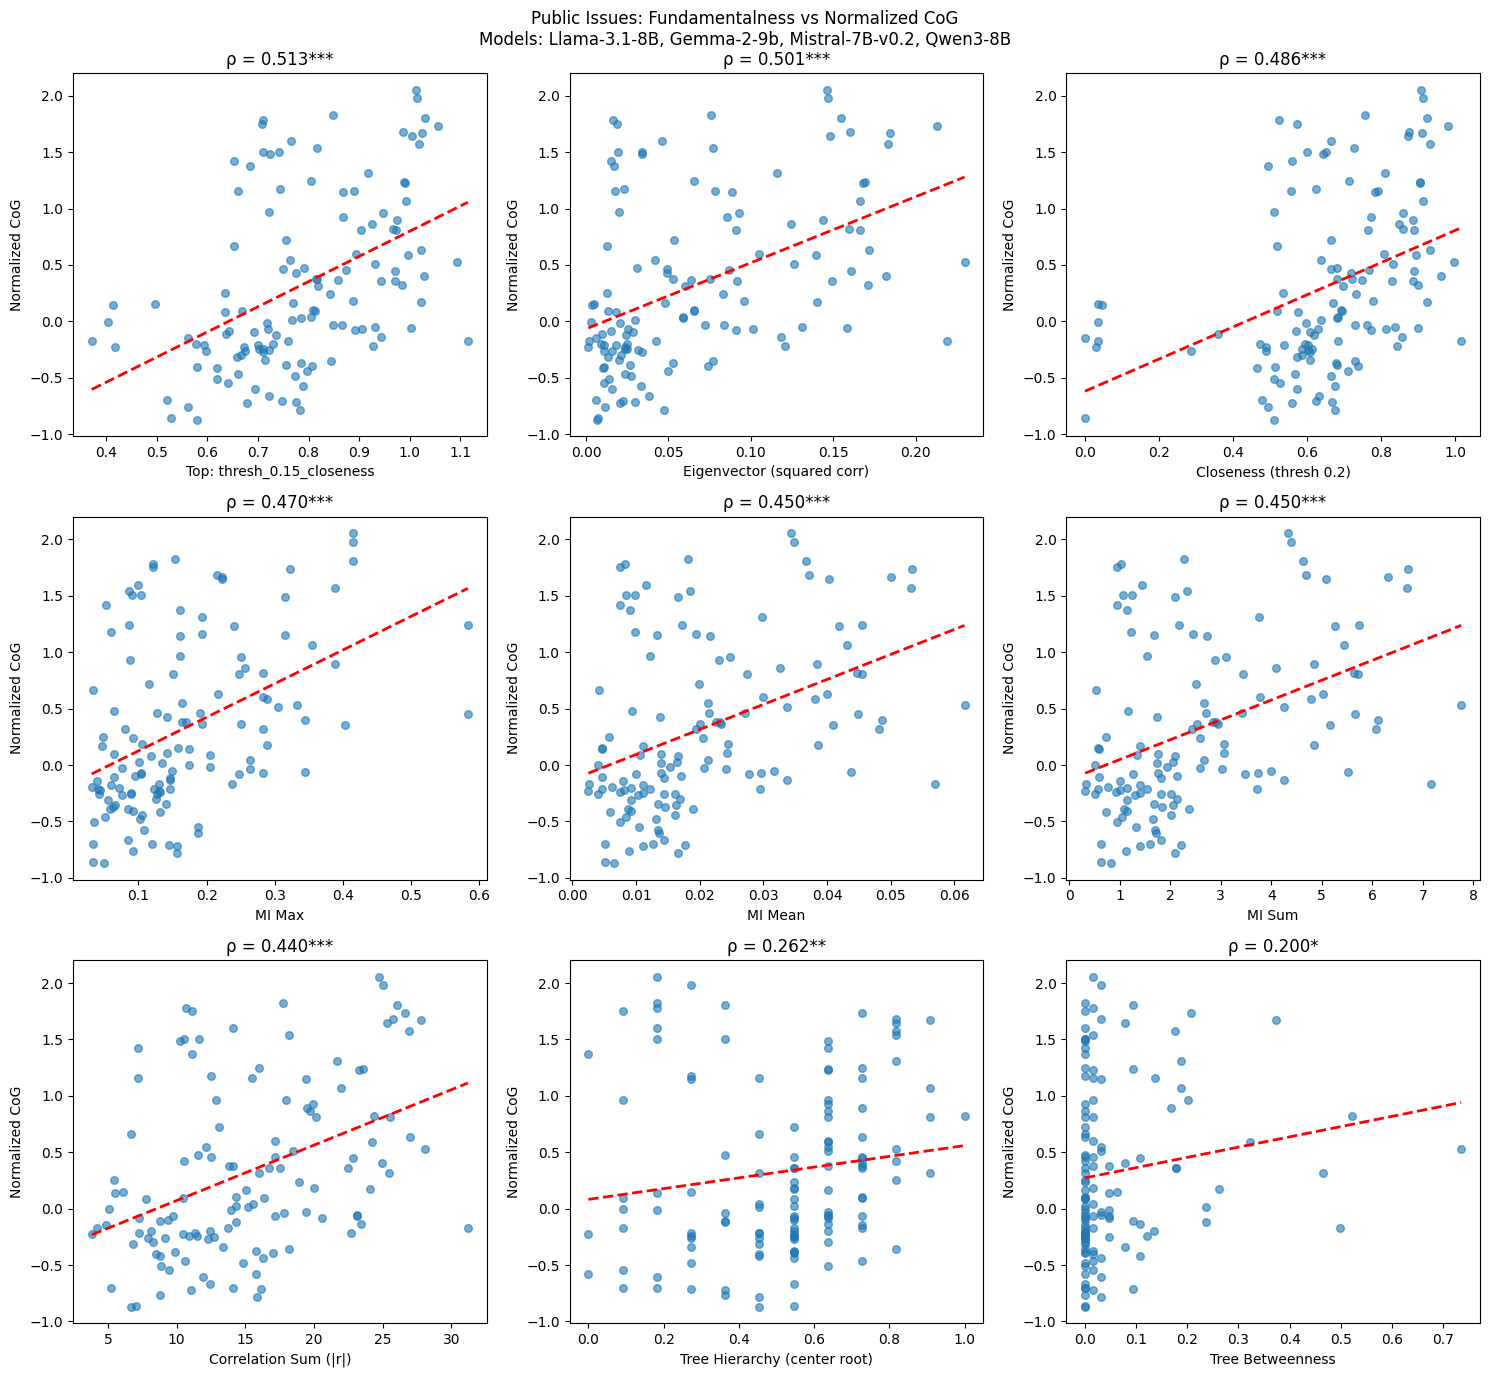

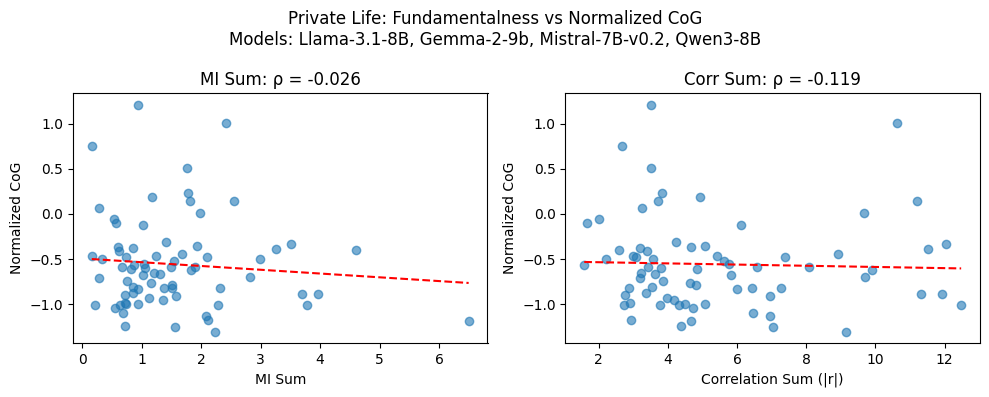

In [41]:
# Scatter plots for PUBLIC ISSUES - multiple measures
fig, axes = plt.subplots(3, 3, figsize=(15, 14))
axes = axes.flatten()

cog_col = 'CoG_normalized'

# Measures to plot for public issues
public_measures = [
    ('complete_squared_eigenvector', 'Eigenvector (squared corr)'),
    ('thresh_0.2_closeness', 'Closeness (thresh 0.2)'),
    ('mi_max', 'MI Max'),
    ('mi_mean', 'MI Mean'),
    ('mi_sum', 'MI Sum'),
    ('corr_abs_sum', 'Correlation Sum (|r|)'),
    ('tree_center_hierarchy', 'Tree Hierarchy (center root)'),
    ('tree_betweenness', 'Tree Betweenness'),
]

# Add top measure if different from above
if len(sig_public) > 0:
    top_pub = sig_public.iloc[0]['measure']
    if top_pub not in [m[0] for m in public_measures]:
        public_measures.insert(0, (top_pub, f'Top: {top_pub}'))

for i, (measure, label) in enumerate(public_measures[:9]):
    ax = axes[i]
    if measure in merged_public.columns:
        valid = merged_public[[cog_col, measure]].dropna()
        ax.scatter(valid[measure], valid[cog_col], alpha=0.6, s=30)
        
        # Fit line
        z = np.polyfit(valid[measure], valid[cog_col], 1)
        p = np.poly1d(z)
        x_line = np.linspace(valid[measure].min(), valid[measure].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=2)
        
        # Stats
        r, p_val = stats.spearmanr(valid[measure], valid[cog_col])
        ax.set_xlabel(label)
        ax.set_ylabel('Normalized CoG')
        ax.set_title(f'ρ = {r:.3f}{stars(p_val)}')
    else:
        ax.set_title(f'{measure}\n(not found)')
        ax.set_visible(False)

# Hide unused axes
for i in range(len(public_measures), 9):
    axes[i].set_visible(False)

plt.suptitle(f'Public Issues: Fundamentalness vs Normalized CoG\nModels: {", ".join(MODELS_TO_USE)}', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cog_fundamentalness_scatter_public_all.png', dpi=150, bbox_inches='tight')
plt.show()

# Separate figure for Private Life
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Private - MI sum
ax = axes[0]
valid = merged_private[[cog_col, 'mi_sum']].dropna()
ax.scatter(valid['mi_sum'], valid[cog_col], alpha=0.6)
z = np.polyfit(valid['mi_sum'], valid[cog_col], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['mi_sum'].min(), valid['mi_sum'].max(), 100)
ax.plot(x_line, p(x_line), 'r--')
ax.set_xlabel('MI Sum')
ax.set_ylabel('Normalized CoG')
r, p_val = stats.spearmanr(valid['mi_sum'], valid[cog_col])
ax.set_title(f'MI Sum: ρ = {r:.3f}{stars(p_val)}')

# Private - corr_abs_sum
ax = axes[1]
valid = merged_private[[cog_col, 'corr_abs_sum']].dropna()
ax.scatter(valid['corr_abs_sum'], valid[cog_col], alpha=0.6)
z = np.polyfit(valid['corr_abs_sum'], valid[cog_col], 1)
p = np.poly1d(z)
x_line = np.linspace(valid['corr_abs_sum'].min(), valid['corr_abs_sum'].max(), 100)
ax.plot(x_line, p(x_line), 'r--')
ax.set_xlabel('Correlation Sum (|r|)')
ax.set_ylabel('Normalized CoG')
r, p_val = stats.spearmanr(valid['corr_abs_sum'], valid[cog_col])
ax.set_title(f'Corr Sum: ρ = {r:.3f}{stars(p_val)}')

plt.suptitle(f'Private Life: Fundamentalness vs Normalized CoG\nModels: {", ".join(MODELS_TO_USE)}', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cog_fundamentalness_scatter_private.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Results

In [42]:
# Save all results
corr_all.to_csv(RESULTS_DIR / 'cog_fundamentalness_correlations_all_measures.csv', index=False)
sig_results.to_csv(RESULTS_DIR / 'cog_fundamentalness_significant_all_measures.csv', index=False)
merged_public.to_csv(RESULTS_DIR / 'cog_fundamentalness_public_merged_all_measures.csv', index=False)
merged_private.to_csv(RESULTS_DIR / 'cog_fundamentalness_private_merged_all_measures.csv', index=False)

print("Files saved:")
print(f"  - {RESULTS_DIR / 'cog_fundamentalness_correlations_all_measures.csv'}")
print(f"  - {RESULTS_DIR / 'cog_fundamentalness_significant_all_measures.csv'}")
print(f"  - {RESULTS_DIR / 'cog_fundamentalness_public_merged_all_measures.csv'}")
print(f"  - {RESULTS_DIR / 'cog_fundamentalness_private_merged_all_measures.csv'}")
print(f"  - {RESULTS_DIR / 'cog_fundamentalness_scatter_all_measures.png'}")

Files saved:
  - /project/jevans/maxzhuyt/gss_polarization/question_fundamentalness/results/cog_fundamentalness_correlations_all_measures.csv
  - /project/jevans/maxzhuyt/gss_polarization/question_fundamentalness/results/cog_fundamentalness_significant_all_measures.csv
  - /project/jevans/maxzhuyt/gss_polarization/question_fundamentalness/results/cog_fundamentalness_public_merged_all_measures.csv
  - /project/jevans/maxzhuyt/gss_polarization/question_fundamentalness/results/cog_fundamentalness_private_merged_all_measures.csv
  - /project/jevans/maxzhuyt/gss_polarization/question_fundamentalness/results/cog_fundamentalness_scatter_all_measures.png


## 9. Summary

In [43]:
print("="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"\n[Configuration]")
print(f"  Models used: {', '.join(MODELS_TO_USE)}")
print(f"  CoG normalization: Z-score within each model before averaging")

print(f"\n[Data]")
print(f"  Public Issues: {len(merged_public)} questions with CoG + fundamentalness")
print(f"  Private Life: {len(merged_private)} questions with CoG + fundamentalness")
print(f"  Total fundamentalness measures: {len(corr_public)} per category")

print(f"\n[Significant Correlations (p < 0.05)]")
print(f"  Public Issues: {n_public_sig} / {n_public_total} measures ({100*n_public_sig/n_public_total:.1f}%)")
print(f"  Private Life: {n_private_sig} / {n_private_total} measures ({100*n_private_sig/n_private_total:.1f}%)")

print(f"\n[Top Correlations by Category]")
if len(sig_public) > 0:
    top = sig_public.iloc[0]
    print(f"  Public Issues: {top['measure']} (ρ = {top['spearman_r']:.3f}{stars(top['spearman_p'])})")
if len(sig_private) > 0:
    top = sig_private.iloc[0]
    print(f"  Private Life: {top['measure']} (ρ = {top['spearman_r']:.3f}{stars(top['spearman_p'])})")
else:
    print(f"  Private Life: (No significant measures)")

print(f"\n[Interpretation]")
print("  Positive correlation: More fundamental questions → Deeper LLM encoding (higher CoG)")
print("  Public issues show strong relationship between network centrality and CoG depth")
print("  Private life questions show no significant relationship with CoG depth")

FINAL SUMMARY

[Configuration]
  Models used: Llama-3.1-8B, Gemma-2-9b, Mistral-7B-v0.2, Qwen3-8B
  CoG normalization: Z-score within each model before averaging

[Data]
  Public Issues: 126 questions with CoG + fundamentalness
  Private Life: 72 questions with CoG + fundamentalness
  Total fundamentalness measures: 71 per category

[Significant Correlations (p < 0.05)]
  Public Issues: 61 / 71 measures (85.9%)
  Private Life: 0 / 77 measures (0.0%)

[Top Correlations by Category]
  Public Issues: thresh_0.15_closeness (ρ = 0.513***)
  Private Life: (No significant measures)

[Interpretation]
  Positive correlation: More fundamental questions → Deeper LLM encoding (higher CoG)
  Public issues show strong relationship between network centrality and CoG depth
  Private life questions show no significant relationship with CoG depth


## 10. Per-Model Analysis

Do the correlations hold when looking at each model individually?

In [60]:
# Load per-model CoG data
df_llm_raw = pd.read_pickle(LLM_COMBINED_FILE)
df_llm_filtered = df_llm_raw[df_llm_raw['model'].isin(MODELS_TO_USE)].copy()

# Key measures to analyze
key_measures = list(set([
    'complete_squared_eigenvector', 'thresh_0.2_closeness', 'mi_max', 
    'mi_mean', 'mi_sum', 'corr_abs_sum', 'corr_abs_mean',
    'tree_center_hierarchy', 'tree_betweenness', 'complete_eigenvector',
    'complete_harmonic', 'complete_strength', 'complete_pagerank',
    'thresh_0.15_closeness', 'thresh_0.15_harmonic', 'complete_squared_eigenvector',
    'complete_squared_katz', 'complete_log_harmonic', 'thresh_0.1_eigenvector',
    'thresh_0.1_closeness', 'thresh_0.1_harmonic', 'thresh_0.15_strength',
    'thresh_0.15_strength', "thresh_0.05_pagerank", "thresh_0.1_degree", "tree_center_depth_norm", "complete_log_betweenness"
]))

def compute_permodel_spearman(fund_df, df_llm, category, measures):
    """Compute Spearman correlations for each model."""
    results = []
    
    for model in MODELS_TO_USE:
        # Get CoG for this model
        model_data = df_llm[df_llm['model'] == model]
        model_cog = model_data[model_data['category'] == category][['Topic', 'Polarization_CoG']]
        model_cog = model_cog.rename(columns={'Topic': 'variable', 'Polarization_CoG': 'CoG'})
        
        # Merge with fundamentalness
        merged = fund_df.merge(model_cog, on='variable', how='inner')
        
        for measure in measures:
            if measure not in merged.columns:
                continue
            valid = merged[['CoG', measure]].dropna()
            if len(valid) >= 10 and valid[measure].std() > 0:
                rho, p = stats.spearmanr(valid['CoG'], valid[measure])
                results.append({
                    'model': model,
                    'measure': measure,
                    'n': len(valid),
                    'rho': rho,
                    'p': p
                })
    
    return pd.DataFrame(results)

# Compute for both categories
permodel_public = compute_permodel_spearman(fund_public, df_llm_filtered, 'public_issues', key_measures)
permodel_private = compute_permodel_spearman(fund_private, df_llm_filtered, 'private_life', key_measures)

print(f"Computed correlations for {len(MODELS_TO_USE)} models")

Computed correlations for 4 models


In [61]:
# PUBLIC ISSUES: Spearman ρ by model
print("="*90)
print("PUBLIC ISSUES: Spearman ρ (Fundamentalness vs CoG) by Model")
print("="*90)

pivot_pub = permodel_public.pivot(index='measure', columns='model', values='rho')
pivot_pub_p = permodel_public.pivot(index='measure', columns='model', values='p')

print(f"\n{'Measure':<32s}", end="")
for model in MODELS_TO_USE:
    print(f"{model[:12]:>14s}", end="")
print()
print("-" * 90)

for measure in pivot_pub.index:
    print(f"{measure:<32s}", end="")
    for model in MODELS_TO_USE:
        rho = pivot_pub.loc[measure, model]
        p = pivot_pub_p.loc[measure, model]
        if pd.notna(rho):
            print(f"{rho:>+10.3f}{stars(p):<4s}", end="")
        else:
            print(f"{'N/A':>14s}", end="")
    print()

# Count significant per model
print("\n" + "-" * 90)
print(f"{'Significant (p<0.05)':<32s}", end="")
for model in MODELS_TO_USE:
    n_sig = (pivot_pub_p[model] < 0.05).sum()
    print(f"{n_sig:>14d}", end="")
print()

PUBLIC ISSUES: Spearman ρ (Fundamentalness vs CoG) by Model

Measure                           Llama-3.1-8B    Gemma-2-9b  Mistral-7B-v      Qwen3-8B
------------------------------------------------------------------------------------------
complete_eigenvector                +0.072        +0.472***     +0.640***     +0.215*   
complete_harmonic                   +0.103        +0.437***     +0.604***     +0.235**  
complete_log_betweenness            +0.167        +0.110        +0.161        +0.329*** 
complete_log_harmonic               +0.091        +0.466***     +0.650***     +0.240**  
complete_pagerank                   +0.081        +0.417***     +0.573***     +0.221*   
complete_squared_eigenvector        +0.077        +0.505***     +0.677***     +0.217*   
complete_squared_katz               +0.103        +0.480***     +0.648***     +0.237**  
complete_strength                   +0.080        +0.430***     +0.588***     +0.218*   
corr_abs_mean                       +0.076     

In [62]:
# PRIVATE LIFE: Spearman ρ by model
print("="*90)
print("PRIVATE LIFE: Spearman ρ (Fundamentalness vs CoG) by Model")
print("="*90)

pivot_priv = permodel_private.pivot(index='measure', columns='model', values='rho')
pivot_priv_p = permodel_private.pivot(index='measure', columns='model', values='p')

print(f"\n{'Measure':<32s}", end="")
for model in MODELS_TO_USE:
    print(f"{model[:12]:>14s}", end="")
print()
print("-" * 90)

for measure in pivot_priv.index:
    print(f"{measure:<32s}", end="")
    for model in MODELS_TO_USE:
        rho = pivot_priv.loc[measure, model]
        p = pivot_priv_p.loc[measure, model]
        if pd.notna(rho):
            print(f"{rho:>+10.3f}{stars(p):<4s}", end="")
        else:
            print(f"{'N/A':>14s}", end="")
    print()

# Count significant per model
print("\n" + "-" * 90)
print(f"{'Significant (p<0.05)':<32s}", end="")
for model in MODELS_TO_USE:
    n_sig = (pivot_priv_p[model] < 0.05).sum()
    print(f"{n_sig:>14d}", end="")
print()

PRIVATE LIFE: Spearman ρ (Fundamentalness vs CoG) by Model

Measure                           Llama-3.1-8B    Gemma-2-9b  Mistral-7B-v      Qwen3-8B
------------------------------------------------------------------------------------------
complete_eigenvector                -0.571***     -0.145        +0.041        +0.300*   
complete_harmonic                   -0.529***     -0.075        +0.059        +0.313**  
complete_log_betweenness            -0.310**      +0.004        +0.145        +0.187    
complete_log_harmonic               -0.536***     -0.086        +0.034        +0.291*   
complete_pagerank                   -0.581***     -0.141        -0.015        +0.251*   
complete_squared_eigenvector        -0.563***     -0.135        +0.100        +0.329**  
complete_squared_katz               -0.539***     -0.085        +0.052        +0.285*   
complete_strength                   -0.580***     -0.143        -0.013        +0.258*   
corr_abs_mean                       -0.579***   

SUMMARY: Per-Model Results

[Public Issues]
  Llama-3.1-8B: 1/25 significant, avg ρ = +0.078
  Gemma-2-9b: 23/25 significant, avg ρ = +0.411
  Mistral-7B-v0.2: 24/25 significant, avg ρ = +0.565
  Qwen3-8B: 22/25 significant, avg ρ = +0.218

[Private Life]
  Llama-3.1-8B: 23/25 significant, avg ρ = -0.419
  Gemma-2-9b: 0/25 significant, avg ρ = -0.054
  Mistral-7B-v0.2: 0/25 significant, avg ρ = +0.032
  Qwen3-8B: 15/25 significant, avg ρ = +0.194


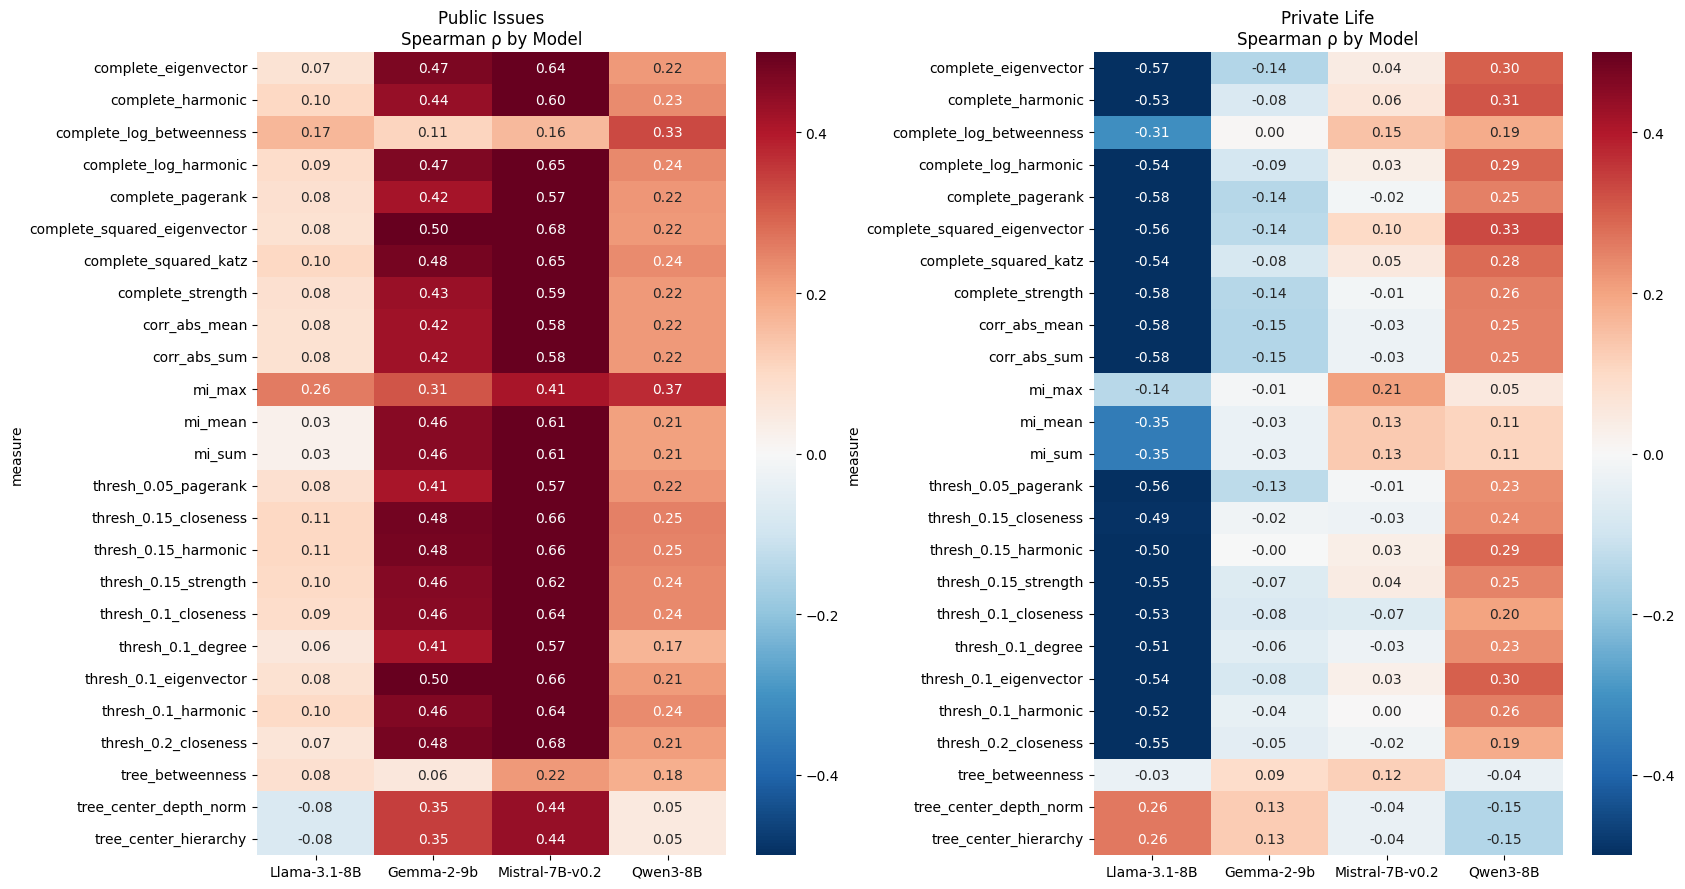

In [64]:
# Summary and Heatmap Visualization
print("="*90)
print("SUMMARY: Per-Model Results")
print("="*90)

print("\n[Public Issues]")
for model in MODELS_TO_USE:
    n_sig = (pivot_pub_p[model] < 0.05).sum()
    n_total = pivot_pub_p[model].notna().sum()
    avg_rho = pivot_pub[model].mean()
    print(f"  {model}: {n_sig}/{n_total} significant, avg ρ = {avg_rho:+.3f}")

print("\n[Private Life]")
for model in MODELS_TO_USE:
    n_sig = (pivot_priv_p[model] < 0.05).sum()
    n_total = pivot_priv_p[model].notna().sum()
    avg_rho = pivot_priv[model].mean()
    print(f"  {model}: {n_sig}/{n_total} significant, avg ρ = {avg_rho:+.3f}")

# Heatmap
fig, axes = plt.subplots(1, 2, figsize=(17, 9))

ax = axes[0]
sns.heatmap(pivot_pub[MODELS_TO_USE], annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-0.5, vmax=0.5, ax=ax)
ax.set_title('Public Issues\nSpearman ρ by Model')
ax.set_xlabel('')

ax = axes[1]
sns.heatmap(pivot_priv[MODELS_TO_USE], annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-0.5, vmax=0.5, ax=ax)
ax.set_title('Private Life\nSpearman ρ by Model')
ax.set_xlabel('')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'cog_fundamentalness_permodel_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()